In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
np.random.seed(42)
n = 500

In [2]:
MedInc = np.random.lognormal(mean=2.5, sigma=0.35, size=n)
HouseAge = np.random.randint(1, 52, size=n)
Longitude = -124 + np.random.rand(n) * 10
Latitude = 32 + np.random.rand(n) * 8
AveRooms = 5 + (0.15 * MedInc) + (0.03 * HouseAge) + np.random.randn(n)

# target 
target = (
    (0.45 * MedInc) 
  - (0.02 * HouseAge)
  - (0.3 * (Latitude - 36))
  - (0.1 * (Longitude + 119))
  + (0.2 * (AveRooms))
  + (np.random.randn(n) * 0.5)
)

df = pd.DataFrame(
    {
        "MedInc" : MedInc,
        "HouseAge" : HouseAge,
        "Longitude" : Longitude,
        "Latitude" : Latitude,
        "AveRooms" : AveRooms,
        "target" : target
    }
)

numeric_cols = df.columns.tolist()

In [3]:
df

,MedInc,HouseAge,Longitude,Latitude,AveRooms,target
0,14.495670,26,-114.506932,38.019422,8.466088,6.988075
1,11.606990,34,-120.033506,32.723854,6.905718,7.808523
2,15.282234,45,-114.459131,34.309485,10.329323,8.190793
3,20.760672,6,-122.649987,32.872877,9.968039,12.969852
4,11.223910,37,-119.162451,37.204093,8.222399,4.573546
...,...,...,...,...,...,...
495,14.711338,36,-122.407126,37.919891,9.222582,7.178993
496,8.473671,49,-117.950461,39.602502,6.870783,2.588243
497,11.397357,39,-120.818884,33.623491,7.665891,6.163946
498,8.966843,40,-115.335613,36.524400,8.105333,4.556732


In [4]:
cov_mat = df[numeric_cols].cov()
corr_mat = df[numeric_cols].corr()

In [5]:
cov_mat

,MedInc,HouseAge,Longitude,Latitude,AveRooms,target
MedInc,22.967083,-3.195884,0.114125,0.693929,3.275102,10.828852
HouseAge,-3.195884,222.304108,-2.161848,-0.079785,5.949806,-3.986233
Longitude,0.114125,-2.161848,8.643836,0.390318,-0.140003,-0.892071
Latitude,0.693929,-0.079785,0.390318,5.030792,-0.048656,-1.255651
AveRooms,3.275102,5.949806,-0.140003,-0.048656,1.586932,1.697932
target,10.828852,-3.986233,-0.892071,-1.255651,1.697932,6.003949


In [6]:
corr_mat

,MedInc,HouseAge,Longitude,Latitude,AveRooms,target
MedInc,1.000000,-0.044726,0.008100,0.064557,0.542491,0.922170
HouseAge,-0.044726,1.000000,-0.049317,-0.002386,0.316774,-0.109111
Longitude,0.008100,-0.049317,1.000000,0.059190,-0.037801,-0.123831
Latitude,0.064557,-0.002386,0.059190,1.000000,-0.017220,-0.228472
AveRooms,0.542491,0.316774,-0.037801,-0.017220,1.000000,0.550076
target,0.922170,-0.109111,-0.123831,-0.228472,0.550076,1.000000


In [7]:
print('Covariance Matrix:\n', cov_mat, "\n")
print('Correlation Matrix:\n', corr_mat, "\n")

Covariance Matrix:
               MedInc    HouseAge  Longitude  Latitude  AveRooms     target
MedInc     22.967083   -3.195884   0.114125  0.693929  3.275102  10.828852
HouseAge   -3.195884  222.304108  -2.161848 -0.079785  5.949806  -3.986233
Longitude   0.114125   -2.161848   8.643836  0.390318 -0.140003  -0.892071
Latitude    0.693929   -0.079785   0.390318  5.030792 -0.048656  -1.255651
AveRooms    3.275102    5.949806  -0.140003 -0.048656  1.586932   1.697932
target     10.828852   -3.986233  -0.892071 -1.255651  1.697932   6.003949 

Correlation Matrix:
              MedInc  HouseAge  Longitude  Latitude  AveRooms    target
MedInc     1.000000 -0.044726   0.008100  0.064557  0.542491  0.922170
HouseAge  -0.044726  1.000000  -0.049317 -0.002386  0.316774 -0.109111
Longitude  0.008100 -0.049317   1.000000  0.059190 -0.037801 -0.123831
Latitude   0.064557 -0.002386   0.059190  1.000000 -0.017220 -0.228472
AveRooms   0.542491  0.316774  -0.037801 -0.017220  1.000000  0.550076
target

In [8]:
y = df["target"].values.reshape(-1,1)
X = df[["MedInc", "AveRooms", "HouseAge", "Latitude", "Longitude"]].values

In [9]:
XtX = X.T @ X
XtX_inv = np.linalg.inv(XtX)
beta = XtX_inv @ X.T @ y

y_hat = X @ beta

resid = y - y_hat

H = X @ XtX_inv @ X.T

leverage = np.diag(H)

print(leverage)



[0.00716159 0.00844413 0.01408987 0.02184983 0.00429377 0.00363699
 0.01170095 0.00409888 0.01298956 0.02004416 0.02000181 0.01125825
 0.00234209 0.0090851  0.00677085 0.00391568 0.00444953 0.00703757
 0.00873464 0.01154218 0.00957694 0.00665284 0.00684896 0.01179716
 0.01327239 0.00303293 0.011155   0.00842512 0.00745521 0.00279771
 0.01261319 0.02021371 0.00631714 0.0155859  0.01159935 0.00613634
 0.00510555 0.018697   0.01324469 0.0034197  0.00562677 0.0087702
 0.00501241 0.00784706 0.00864927 0.00821474 0.0072518  0.01550617
 0.00571816 0.0156292  0.00446867 0.00472426 0.00463717 0.00993394
 0.01440882 0.01969    0.00877429 0.01308522 0.00704663 0.00880683
 0.00397642 0.00699333 0.00844003 0.00768161 0.00457698 0.01278514
 0.0114409  0.0070369  0.01081139 0.01271357 0.00682801 0.01261825
 0.00281993 0.01199783 0.01059717 0.01638579 0.00519933 0.0054284
 0.01443269 0.00695402 0.00905185 0.01234914 0.01897185 0.00512142
 0.00639704 0.00597023 0.00463653 0.00645896 0.01089413 0.004916

In [10]:
print("H: ",H.shape)
print("y: ",y.shape)
print("X: ",X.shape)
print("beta: ",beta.shape)

H:  (500, 500)
y:  (500, 1)
X:  (500, 5)
beta:  (5, 1)


In [11]:
summary = pd.DataFrame({
    "index" : np.arange(n),
    "leverage" : leverage,
    "y" : y.flatten(),
    "y_hat" : y_hat.flatten(),
    "resid" : resid.flatten(),
})

In [12]:
summary

,index,leverage,y,y_hat,resid
0,0,0.007162,6.988075,6.668098,0.319977
1,1,0.008444,7.808523,7.068520,0.740003
2,2,0.014090,8.190793,8.162001,0.028792
3,3,0.021850,12.969852,12.451499,0.518352
4,4,0.004294,4.573546,5.633209,-1.059663
...,...,...,...,...,...
495,495,0.004781,7.178993,7.493624,-0.314631
496,496,0.015279,2.588243,3.089605,-0.501362
497,497,0.006421,6.163946,6.823236,-0.659290
498,498,0.007181,4.556732,4.390510,0.166222


In [13]:
print("Top Ten Leverage Points")
print(summary.sort_values(by="leverage", ascending=False).head(10).round(3))

Top Ten Leverage Points
     index  leverage       y   y_hat  resid
209    209     0.116  24.706  24.651  0.054
478    478     0.049  18.365  18.069  0.295
179    179     0.035  15.024  15.778 -0.753
416    416     0.030  11.599  12.271 -0.671
362    362     0.029   6.400   6.942 -0.542
378    378     0.029  12.418  13.075 -0.657
323    323     0.027  10.343  11.019 -0.676
113    113     0.025  14.024  13.938  0.087
234    234     0.025  11.089  11.442 -0.353
247    247     0.025   3.930   4.186 -0.256


In [14]:
n, p = X.shape
print("n: ", n)
print("p: ", p)

avg_lev = p/n
threshold = 2 * avg_lev
print("avg_lev: ", avg_lev)
print("threshold: ", threshold)

n:  500
p:  5
avg_lev:  0.01
threshold:  0.02


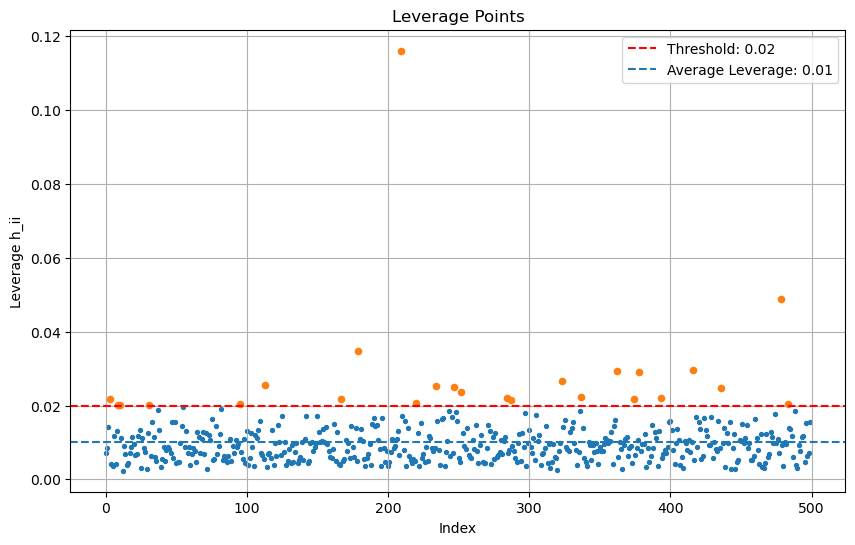

In [15]:
#Plotting leverage points
plt.figure(figsize=(10,6))
plt.scatter(summary["index"], summary["leverage"], s=8)
plt.axhline(y = threshold, color = 'r', linestyle = '--', label=f'Threshold: {threshold}')
plt.axhline(avg_lev, linestyle='--', label=f'Average Leverage: {avg_lev:.2f}')
hi_idx = summary.index[summary['leverage'] > threshold].tolist()
if len(hi_idx) > 0:
    plt.scatter(hi_idx, summary.loc[hi_idx, 'leverage'], s=20)
plt.grid(True)
plt.title('Leverage Points')
plt.xlabel('Index')
plt.ylabel('Leverage h_ii')
plt.legend()

In [18]:
np.random.seed(0)

house_size = np.random.normal(2000,400,100)
house_price = 100 + 0.5 * house_size + np.random.normal(0, 20000, 100)

# Add few mansions
house_size = np.append(house_size, [5000, 6000, 7000])
house_price = np.append(house_price, [450000, 550000, 80000])

# Fit a linear model
X = sm.add_constant(house_size)
model = sm.OLS(house_price, X).fit()

In [19]:
# Printing model parameter
print("Model with mansions:")
print(f"Intercept: {model.params[0]:.2f}")
print(f"Slope: {model.params[1]:.2f}")

Model with mansions:
Intercept: -115578.82
Slope: 60.16


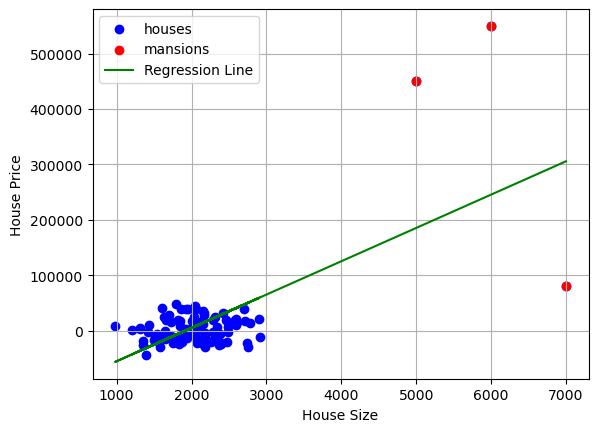

In [20]:
# Plot the data
plt.scatter(house_size, house_price, label="houses", color='blue')
plt.scatter(house_size[-3:], house_price[-3:], label="mansions", color='red')
plt.plot(house_size, model.params[0] + model.params[1]*house_size, color='green', label="Regression Line")
plt.xlabel("House Size")
plt.ylabel("House Price")
plt.legend()
plt.grid(True)
plt.show()

In [23]:
influence = model.get_influence()
leverage = influence.hat_matrix_diag
residuals = model.resid

#Threshold
n = len(house_size)
p = X.shape[1]
avg_len = p/n
threshold = 2 * avg_len
print(threshold)

0.038834951456310676


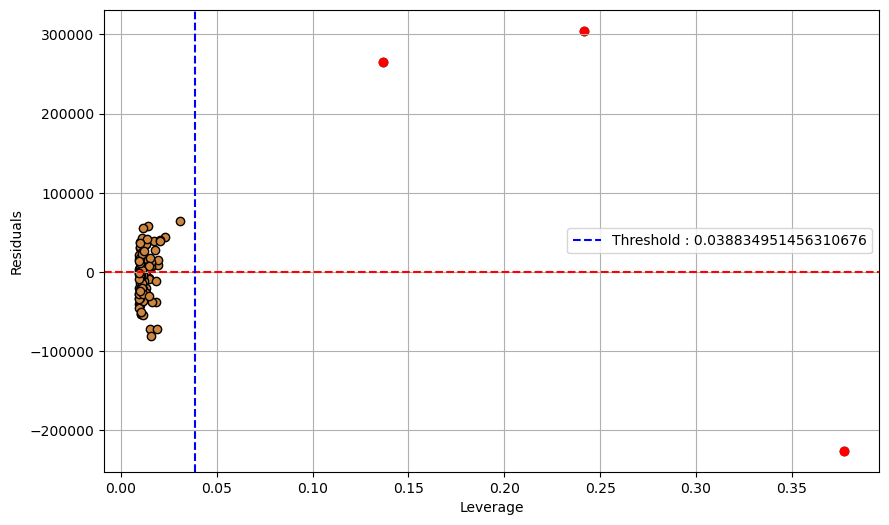

In [32]:
plt.figure(figsize=(10,6))
plt.scatter(leverage, residuals, edgecolors='k', facecolor='peru')
plt.axhline(0, color="red", linestyle='--')
plt.axvline(threshold, color="blue", linestyle='--', label=f'Threshold : {threshold}')
plt.xlabel('Leverage')
plt.ylabel('Residuals')
plt.grid(True)
plt.legend()

high_leverage_points = np.where(leverage > threshold)[0]
plt.scatter(leverage[high_leverage_points], 
            residuals[high_leverage_points], 
            color='red',label="High Leverage points")
plt.show()

In [38]:
print(f"High leverage points (index):  {high_leverage_points}")
print(f"Leverage values:  {leverage[high_leverage_points]}")

High leverage points (index):  [100 101 102]
Leverage values:  [0.13694378 0.24146323 0.37708716]


Exercise 1:
Use the Boston Housing dataset, analyze it, and identify its leverage points. This dataset is available in the section

Exercise 2:
Use the diamonds dataset, analyze it, and identify its leverage points. This dataset is available in the seaborn

In [6]:
import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [7]:
from sklearn.datasets import fetch_openml
housing = fetch_openml(name="house_prices", as_frame=True)

In [8]:
housing

{'data':         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
 0        1          60       RL         65.0     8450   Pave   NaN      Reg   
 1        2          20       RL         80.0     9600   Pave   NaN      Reg   
 2        3          60       RL         68.0    11250   Pave   NaN      IR1   
 3        4          70       RL         60.0     9550   Pave   NaN      IR1   
 4        5          60       RL         84.0    14260   Pave   NaN      IR1   
 ...    ...         ...      ...          ...      ...    ...   ...      ...   
 1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
 1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
 1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
 1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
 1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   
 
      LandContour Utilities  .